In [8]:
print("Hello, World!")

Hello, World!


### SETUP AND DATA LOADING

In [115]:
#import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [116]:
#load the dataset
df = pd.read_csv(r'C:\Users\ifean\OneDrive\Desktop\my project\Nova-pay-fraud-detection-system\data\nova_pay_combined.csv')

In [117]:
#to check the first 5 rows of the dataset
print(df.head(20))

                          transaction_id  \
0   fee8542d-8ee6-4b0d-9671-c294dd08ed26   
1   bfdb9fc1-27fe-4a85-b043-4d813d679259   
2   fc855034-3ea5-4993-9afa-b511d93fe5e8   
3   2cf8c08e-42ec-444d-a755-34b9a2a0a4ca   
4   d907a74d-b426-438d-97eb-dbe911aca91c   
5   ec17d6f2-6505-4de9-910f-0de3ac3bbc23   
6   2d8efe37-33ea-40de-9881-e553e3f2f8ce   
7   4d311532-ee0b-4985-b996-63e11a7144d3   
8   db5bdea7-0701-4c07-9efa-815fa6ca9ede   
9   d74c81c0-bf5d-4184-8ce2-27fb753cb1c6   
10  ff57e293-80cf-4e72-baa4-37011f79b0ff   
11  43a11314-6420-4e23-b0a8-69d5f010da86   
12  2743f55c-3693-4219-a62c-5b3d22caf2c6   
13  1a34a095-3be4-4a69-a22e-803be566526c   
14  293c5ffb-ea4a-4ddb-855d-b159d7faee37   
15  d48dbfbf-2b25-47e0-8470-66e8996faa0f   
16  939c7f20-585e-4534-b346-2c879ac977d7   
17  0517c799-0f40-4d7c-b720-2f4969b2564f   
18  61d9b774-8426-4edc-bc73-272dbb254f60   
19  25f9e6ad-9036-4158-900d-dfdd51b05d1c   

                             customer_id                         timestamp 

In [41]:
#Check shape and columns of the dataset
print("Shape of the dataset:", df.shape)

Shape of the dataset: (11400, 26)


In [97]:
#inspect data types
print("Data types of the dataset:\n", df.dtypes)

Data types of the dataset:
 transaction_id                               str
customer_id                                  str
timestamp                    datetime64[us, UTC]
home_country                                 str
source_currency                              str
dest_currency                                str
channel                                      str
amount_src                               float64
amount_usd                               float64
fee                                      float64
exchange_rate_src_to_dest                float64
device_id                                    str
new_device                                  bool
ip_address                                   str
ip_country                                   str
location_mismatch                           bool
ip_risk_score                            float64
kyc_tier                                     str
account_age_days                           int64
device_trust_score                       

timestamp and amount_src has inconsistentcy

In [43]:
#Check for missing values in the dataset
print("Missing values in the dataset:\n", df.isnull().sum())

Missing values in the dataset:
 transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     0
amount_usd                   305
fee                          295
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                   301
location_mismatch              0
ip_risk_score                  0
kyc_tier                     300
account_age_days               0
device_trust_score           295
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64


In [82]:
#find duplicate in the dataset
df.duplicated().sum()

np.int64(200)

In [47]:
#review summary statistics of the dataset
print("Summary statistics of the dataset:\n", df.describe())


Summary statistics of the dataset:
          amount_usd           fee  exchange_rate_src_to_dest  ip_risk_score  \
count  11095.000000  11105.000000               11400.000000   11400.000000   
mean     452.022083    100.309441                 167.540397       0.396726   
std     1403.973062    958.128504                 382.023827       0.270507   
min        7.230000     -1.000000                   0.592000       0.004000   
25%       92.465000      2.380000                   1.000000       0.209000   
50%      163.480000      3.500000                   7.142857       0.325000   
75%      302.190000      5.550000                  73.529412       0.487000   
max    12498.570000   9999.990000                1388.888889       1.200000   

       account_age_days  device_trust_score  chargeback_history_count  \
count      11400.000000        11105.000000              11400.000000   
mean         393.793158            0.653681                  0.048509   
std          342.348393          

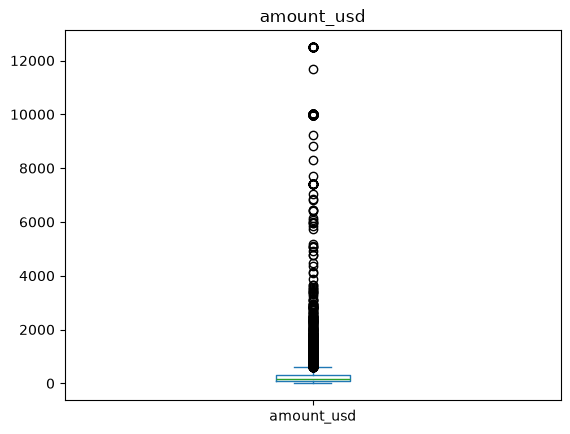

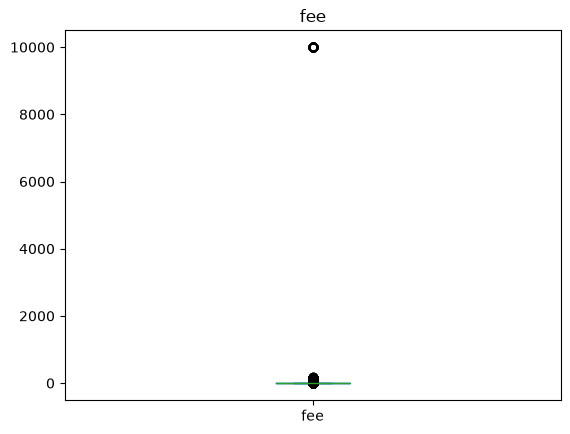

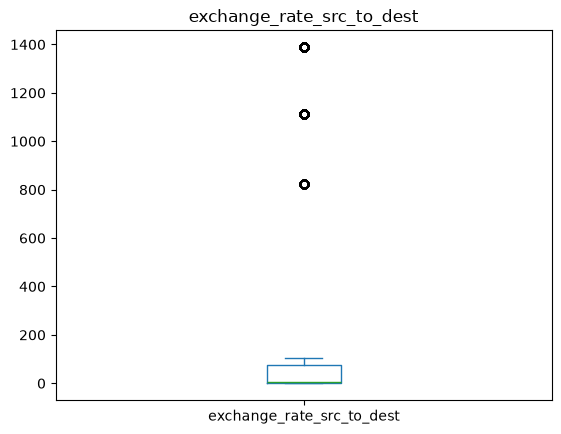

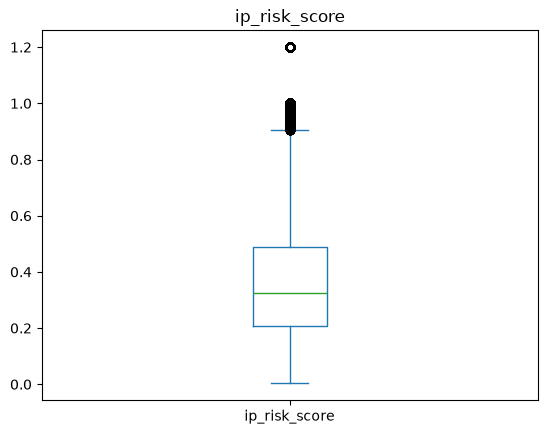

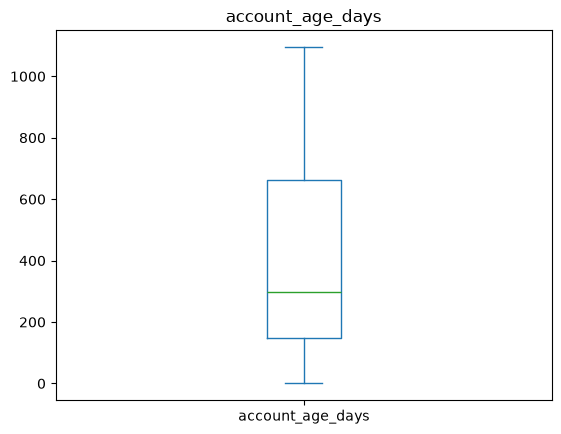

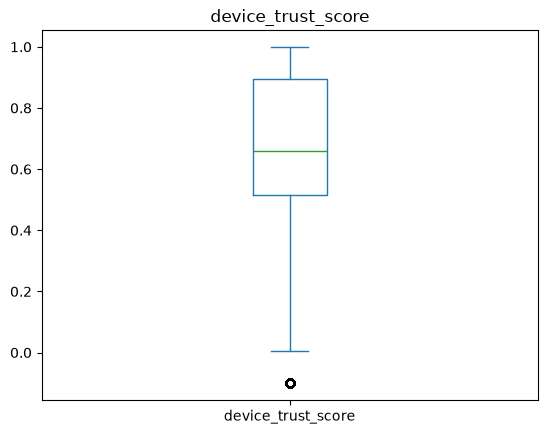

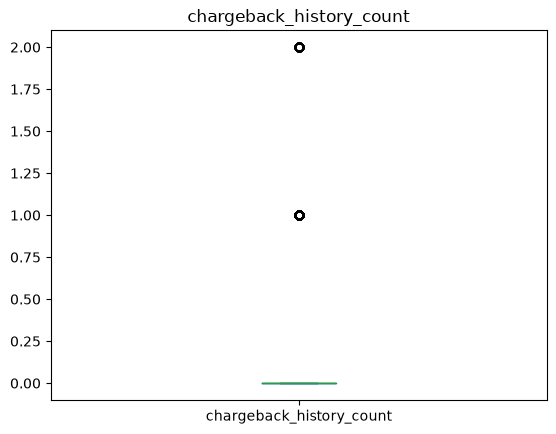

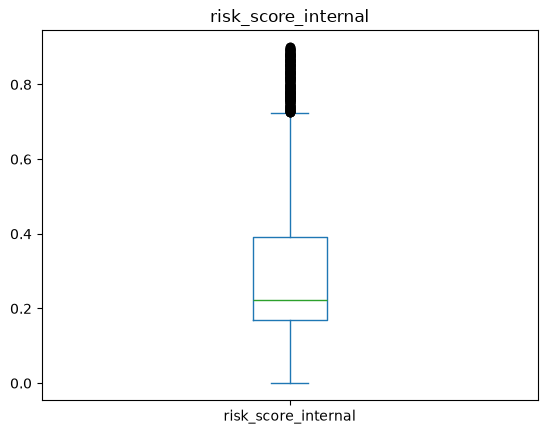

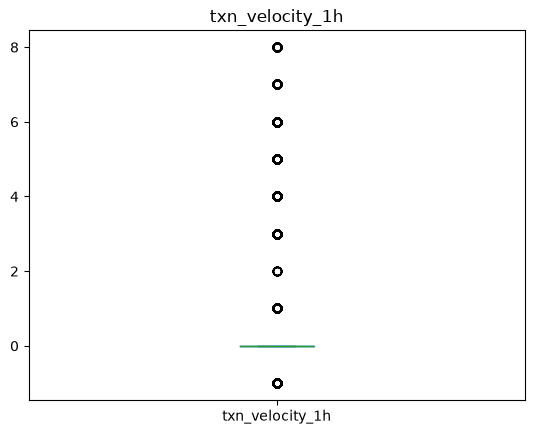

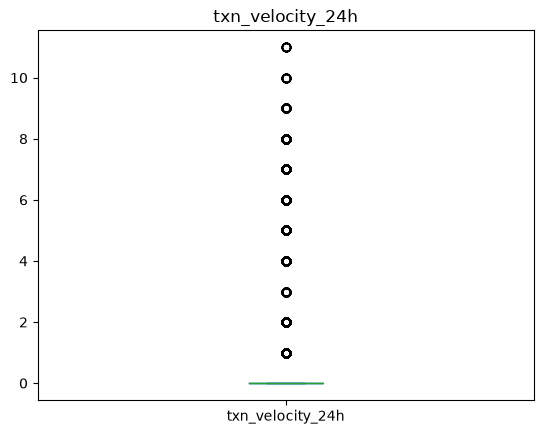

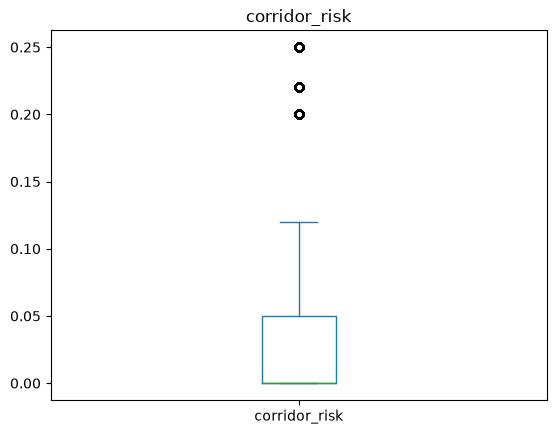

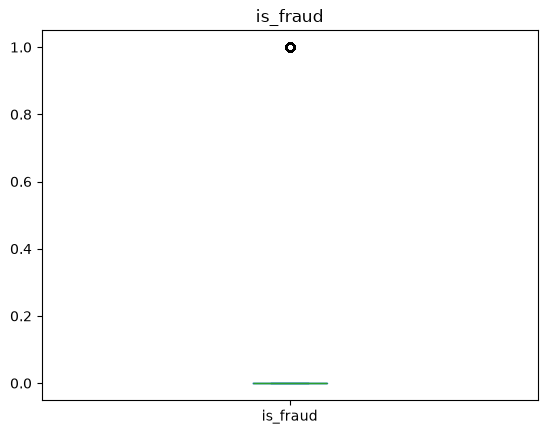

In [118]:
#check for outliers and unusual patterns in the dataset using boxplots
import numpy as np

for column in df.select_dtypes(include=np.number).columns.tolist():
    df[column].plot(kind='box', title=column)
    plt.show()

In [51]:
#convert transaction id from text-string to text 
df['transaction_id'] = df['transaction_id'].astype(str)

In [77]:
#check for mean in the dataset
for column in df.select_dtypes(include=['float64', 'int64']).columns.tolist():
    print(f"Column: {column}")
    print(f"Mean: {df[column].mean()}")
    print("---------------------------------")

Column: amount_usd
Mean: 452.0220829202343
---------------------------------
Column: fee
Mean: 100.30944079243582
---------------------------------
Column: exchange_rate_src_to_dest
Mean: 167.54039719350877
---------------------------------
Column: ip_risk_score
Mean: 0.3967261403508773
---------------------------------
Column: account_age_days
Mean: 393.79315789473685
---------------------------------
Column: device_trust_score
Mean: 0.6536807744259343
---------------------------------
Column: chargeback_history_count
Mean: 0.048508771929824564
---------------------------------
Column: risk_score_internal
Mean: 0.26713368421052636
---------------------------------
Column: txn_velocity_1h
Mean: 0.4583333333333333
---------------------------------
Column: txn_velocity_24h
Mean: 0.7235087719298245
---------------------------------
Column: corridor_risk
Mean: 0.04550087719298246
---------------------------------
Column: is_fraud
Mean: 0.08745614035087719
---------------------------------


In [78]:
round(df.isnull().mean()* 100, 2)

transaction_id               0.00
customer_id                  0.00
timestamp                    0.25
home_country                 0.00
source_currency              0.00
dest_currency                0.00
channel                      0.00
amount_src                   0.00
amount_usd                   2.68
fee                          2.59
exchange_rate_src_to_dest    0.00
device_id                    0.00
new_device                   0.00
ip_address                   2.68
ip_country                   2.64
location_mismatch            0.00
ip_risk_score                0.00
kyc_tier                     2.63
account_age_days             0.00
device_trust_score           2.59
chargeback_history_count     0.00
risk_score_internal          0.00
txn_velocity_1h              0.00
txn_velocity_24h             0.00
corridor_risk                0.00
is_fraud                     0.00
dtype: float64

### Due to servral inconsistency we perform a major categorical audit ###

In [105]:
for column in df.select_dtypes(include=['string']).columns.tolist():
    print(df[column].value_counts())
    print("---------------------------------")

transaction_id
4662cb2d-21b2-4390-ba38-5a1eddebdc7c    2
e69d481f-2ee3-4621-a58a-73fec8c63eca    2
8537371a-7eae-4108-89c9-5660e5025a88    2
2e553c23-063e-4b5e-aa2e-8a41d6aa61ca    2
a9198fb0-d831-48df-b434-c30a39078aa3    2
                                       ..
b5ef3323-46d2-4f6c-9c19-43df4e55df48    1
54f00f78-94aa-4a08-bf6b-12877aa47186    1
6a51f0e8-f5d1-4fe6-91a0-655fccd79fa5    1
4aad7389-2b62-4885-a23e-aa3ecd5cfaf9    1
fdffeb16-192a-4483-9b1e-9928e23269c2    1
Name: count, Length: 11096, dtype: int64
---------------------------------
customer_id
402cccc9-28de-45b3-9af7-cc5302aa1f93    1500
d71c91b4-fee8-4104-9856-a5c6109a62e3    1341
7041b9c1-3719-4ca8-9a6b-811b47cea6c0    1326
6d0d9b27-fa26-45f8-93b1-2df29d182d9c    1057
af8ca4c4-8703-4c55-b66c-2b76cd70040d     904
                                        ... 
8734e6a7-f34e-49f2-b559-1d62a756664c       1
c18070a6-bdb9-4df3-9df7-5d92c0bff424       1
2003e2a1-f3b1-4e2e-8d0e-488cfacf68ca       1
8b1cf558-4ed7-48ee-b330-75db6ef

Issues detected;
-Channel:typo(mobille/weeb),inconsistent casing(MOBILE,WEB,ATm),leaving white space and an unknown placeholder.
-kyc#-tier:typo(standrd,enhancd),inconsistent casing, whitespace, and nan/NAN placeholders.
-home_country/ip_country:leaving whitespace and an unknown placeholder.

standardization will be done in the section.

DATA CLEANING AND STANDARDIZATION



Operating on datatypes

In [94]:
#reparse timestamp and amount_src
pd.to_datetime(df['timestamp'], errors='coerce', dayfirst=True)


0       2022-03-10 18:40:59.468549+00:00
1       2022-03-10 20:39:38.468549+00:00
2       2022-03-10 23:02:43.468549+00:00
3       2022-04-10 01:08:53.468549+00:00
4       2022-04-10 09:35:03.468549+00:00
                      ...               
11395                                NaT
11396                                NaT
11397                                NaT
11398                                NaT
11399                                NaT
Name: timestamp, Length: 11400, dtype: datetime64[us, UTC]

In [106]:

pd.to_numeric(df['amount_src'], errors='coerce')

0         278.19
1         208.51
2         160.33
3          59.41
4         200.96
          ...   
11395     271.25
11396     537.17
11397     205.15
11398      78.03
11399    1214.16
Name: amount_src, Length: 11293, dtype: float64

In [108]:
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce', dayfirst=True)
df['amount_src'] = pd.to_numeric(df['amount_src'], errors='coerce')

In [112]:
#restore rows with zero or negative values in the amount_src column
df = df[df['amount_src'] > 0]

#restore rows with zero or negative values in the amount_src column
df = df[df['amount_src'] > 0].copy()

Droping dupliates then using Id columns as the subsets

In [125]:
#Drop duplicate using Id columns as a reference

df.drop_duplicates(subset=['transaction_id'], ignore_index=True, keep='first', inplace=True) 
print("Shape of the dataset after dropping duplicates:", df.shape)


Shape of the dataset after dropping duplicates: (11200, 26)


In [121]:
#check for duplicate in amount_src column
duplicate_amount_src = df[df.duplicated(subset='amount_src', keep=False)]
print("Duplicate rows based on 'amount_src' column:\n", duplicate_amount_src)

Duplicate rows based on 'amount_src' column:
                              transaction_id  \
22     ea2f7e46-714b-4c1d-ae81-f0bf0c47313b   
23     fec2c143-ef9b-4274-b99f-713d1ed511b7   
27     cb118fb8-a30f-4e5b-b288-3975a35def8e   
28     dd3f2150-2bbd-4489-99b6-7b99c4f4f05c   
34     8fe20fa1-61c3-4eae-a3ed-160718e0b209   
...                                     ...   
11377  6fc79155-bbcc-4d0a-8aca-54ad5f8db57d   
11379  c574760d-994b-4580-b435-cecf0261f85a   
11382  e42b36ae-0db9-481d-87d6-025cbb899edc   
11394  aa86c811-0a65-421a-b4aa-781a40f5111e   
11398  4aad7389-2b62-4885-a23e-aa3ecd5cfaf9   

                                customer_id                         timestamp  \
22     6d0d9b27-fa26-45f8-93b1-2df29d182d9c  2022-10-06 07:38:34.468549+00:00   
23     d71c91b4-fee8-4104-9856-a5c6109a62e3  2022-10-06 07:40:57.468549+00:00   
27     4dfeffe2-94ed-4fc3-b5bc-89c6f1e86dab  2022-10-06 11:15:12.468549+00:00   
28     924a7526-46e2-47d9-90ef-4dd432816253  2022-10-06 18:00:46.

Operating on categorical issues